In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

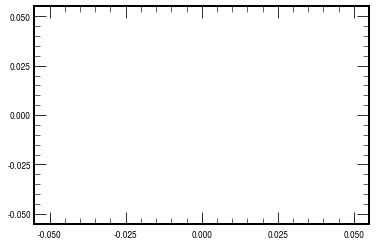

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
def merge_runs(plots, run):
    names = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
        "total_bkg",
    ]
    # Add signal processes
    signal_processes = list(
        set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13TeV", p))
    )
    # Remove 2016APV for now
    # years = ["2016APV", "2016", "2017", "2018"]
    years = ["2016", "2017", "2018"]
    if run == "Run3":
        names.remove("TTV")
        names.remove("ST_NLO")
        years = ["2022", "2022EE", "2023", "2023BPix"]
        # Add signal processes
        signal_processes = list(
            set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13p6TeV", p))
        )
    names.append("Data")
    names.extend(signal_processes)
    run_plots = {}
    for name in names:
        run_plots[f"{name}_{run}"] = {}
        for year in years:
            if f"{name}_{year}" not in plots.keys():
                continue
            for plot in plots[f"{name}_{year}"]:
                if plot not in run_plots[f"{name}_{run}"].keys():
                    run_plots[f"{name}_{run}"][plot] = plots[f"{name}_{year}"][
                        plot
                    ].copy()
                else:
                    run_plots[f"{name}_{run}"][plot] += plots[f"{name}_{year}"][plot]
    return run_plots

In [10]:
plots = {}
years_to_load = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
]
for year in track(years_to_load, description="Loading plots"):
    plots = plots | plot_utils.loader(
        tag=f"full_analysis_Jun2025_{year}_CR",
        era=year,
        load_data=True,
    )
run2_plots = merge_runs(plots, "Run2")
plots = plots | run2_plots
run3_plots = merge_runs(plots, "Run3")
plots = plots | run3_plots

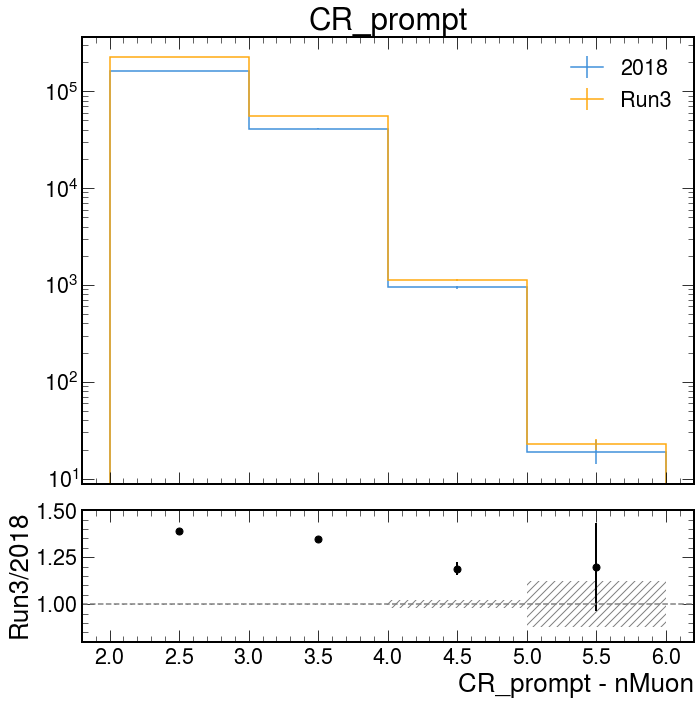

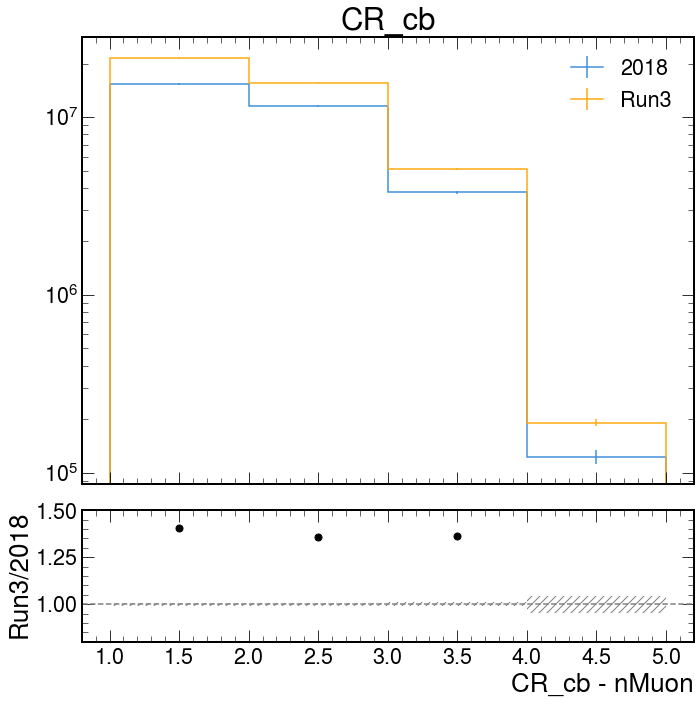

In [11]:
regions = ["prompt", "cb"]

first = "2018"
second = "Run3"

for region in regions:
    hist_run2 = plots[f"total_bkg_{first}"][f"CR_{region}"]
    hist_run3 = plots[f"total_bkg_{second}"][f"CR_{region}"]

    # # Normalize
    # normalization = 59.8 / 62.4
    # hist_run3 = hist_run3 * normalization

    fig = plt.figure(figsize=(10, 10))
    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

    hist_run2.plot(label=f"{first}", ax=ax1)
    hist_run3.plot(label=f"{second}", ax=ax1)

    x_hatch = np.vstack(
        (hist_run3.axes[0].edges[:-1], hist_run3.axes[0].edges[1:])
    ).reshape((-1,), order="F")

    ratio = np.divide(
        hist_run3.values(),
        hist_run2.values(),
        out=np.ones_like(hist_run2.values()),
        where=hist_run3.values() != 0,
    )
    ratio_err = np.where(
        hist_run3.values() > 0,
        np.sqrt(
            (hist_run3.values() ** -2) * (hist_run2.variances())
            + (hist_run2.values() ** 2 * hist_run3.values() ** -4)
            * (hist_run3.variances())
        ),
        0,
    )
    ax2.errorbar(
        hist_run2.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_run3.variances()),
        hist_run3.values(),
        out=np.zeros_like(hist_run3.values()),
        where=hist_run3.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_run3.values()), np.ones_like(hist_run3.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax2.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax2.axhline(1, ls="--", color="gray")

    ax1.set_yscale("log")
    plt.sca(ax2)
    plt.xlabel(f"CR_{region} - nMuon")
    if region == "prompt":
        plt.ylim(0.8, 1.5)
    if region == "cb":
        plt.ylim(0.8, 1.5)
    plt.ylabel(f"{second}/{first}")
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_xlabel("", visible=False)
    ax1.set_title(f"CR_{region}")
    ax1.legend()
    plt.show()